In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load Boston Housing Dataset

In [3]:
df = pd.read_csv("Boston Housing Data.csv")

In [4]:
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


# Display Dataset Information


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


# Define Independent and Dependent Variables

In [6]:
X = df.drop("MEDV", axis=1)  
y = df["MEDV"]

# Split Dataset into Training and Testing Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression Model

In [11]:
model = LinearRegression()

# Check Missing Values in Training Data

In [15]:
import numpy as np

print(np.isnan(X_train).sum())

CRIM       18
ZN         17
INDUS      18
CHAS       16
NOX         0
RM          0
AGE        16
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      15
dtype: int64


# Handle Missing Values and Train Linear Regression Model

In [18]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Predict House Prices

In [19]:
y_pred = model.predict(X_test)

# Evaluate Linear Regression Model

In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


Model Evaluation:
Mean Squared Error: 25.002388923514708
Root Mean Squared Error: 5.000238886644788
R2 Score: 0.6590604241860226


# Display Feature Coefficients

In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("\nFeature Coefficients:")
print(coefficients)


Feature Coefficients:
    Feature  Coefficient
0      CRIM    -0.114150
1        ZN     0.029111
2     INDUS    -0.026948
3      CHAS     3.238392
4       NOX   -16.012529
5        RM     4.747299
6       AGE    -0.019465
7       DIS    -1.522137
8       RAD     0.222853
9       TAX    -0.009160
10  PTRATIO    -0.886274
11        B     0.012239
12    LSTAT    -0.439217


# Visualize Actual vs Predicted House Prices

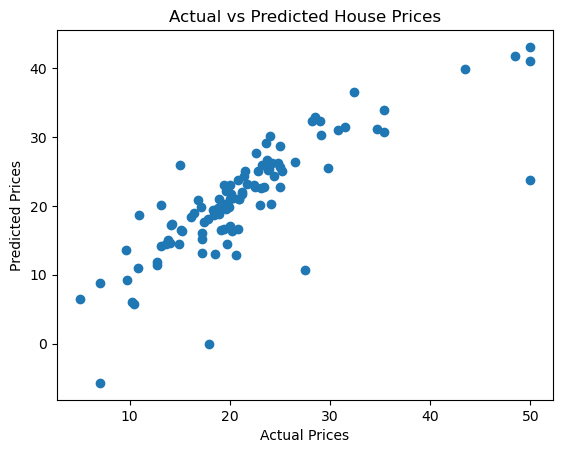

In [25]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()